# v12 — Baseline ML Models + NeuroKit2 (Fatigue Detection)

**Цель:** Сравнить набор базовых ML-алгоритмов (Logistic Regression, Random Forest, Extra Trees, Gradient Boosting, XGBoost) с нейросетью `v8b_t` на задаче классификации усталости. Feature engineering — NeuroKit2, как в Hongn et al. 2025.

---

## Ссылка на исходную работу

> Hongn A, Bosch F, Prado LE, Ferrández JM, Bonomini MP.  
> **Wearable Physiological Signals under Acute Stress and Exercise Conditions.**  
> *Scientific Data*, 12(1):520, 28 Mar 2025.  
> DOI: [10.1038/s41597-025-04845-9](https://doi.org/10.1038/s41597-025-04845-9)

## Ключевые результаты исходной работы

| Задача | Алгоритм | Accuracy |
|--------|----------|----------|
| Stress vs Rest (бинарная) | XGBoost | **93%** |
| Aerobic vs Anaerobic (бинарная) | XGBoost | **91%** |
| Stress / Rest / Aerobic / Anaerobic (4-class) | XGBoost | **84%** |

## ⚠️ Важное замечание о сравнимости

93% из оригинальной работы — это классификация **типа активности (stress vs rest)**, тогда как наша задача — классификация **усталости внутри упражнения** (fatigued vs non-fatigued на временном горизонте сессии AEROBIC/ANAEROBIC). Это принципиально более сложная задача.

## Базовые алгоритмы в этом ноутбуке

| Алгоритм | Примечания |
|----------|-----------|
| Logistic Regression | Линейный baseline, L2-регуляризация |
| Random Forest | Ансамблевый, без переобучения, class_weight |
| Extra Trees | Более рандомизированный RF, быстрее |
| Gradient Boosting | sklearn GBM, последовательный ансамбль |
| XGBoost | Лучший градиентный бустинг |

Все модели используют одни и те же NeuroKit2-признаки (30-сек окна) и одинаковый subject-level LOSO-протокол.


In [17]:
# Cell 2 — Install dependencies
import subprocess, sys
def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        __import__(name)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg} installed.')

ensure('neurokit2')
ensure('xgboost')
ensure('scikit-learn', 'sklearn')
ensure('shap')
print('All dependencies OK')

All dependencies OK


In [18]:
# Cell 3 — Imports
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import neurokit2 as nk
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    average_precision_score, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

# Project root
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

print(f'NeuroKit2: {nk.__version__}')
print(f'XGBoost:   {xgb.__version__}')
print(f'Root:      {ROOT}')

NeuroKit2: 0.2.13
XGBoost:   3.2.0
Root:      D:\Github\afc_lab


In [19]:
# Cell 4 — Configuration
SEED = 1224
np.random.seed(SEED)

DATA_ROOT = ROOT / 'data' / 'raw' / \
    'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1' / \
    'Wearable_Dataset'

RESULTS_DIR = ROOT / 'res' / 'v12_base_all'
RESULTS_DIR.mkdir(exist_ok=True)

# Sampling rates (as per Data_Dictionary.csv)
FS = {
    'BVP':  64,   # Blood Volume Pulse (PPG)
    'EDA':   4,   # Electrodermal Activity
    'TEMP':  4,   # Skin Temperature
    'ACC':  32,   # Accelerometer (per axis)
    'HR':    1,   # Heart Rate (pre-computed)
}

# Window configuration (longer windows for NeuroKit2 HRV)
WIN_SEC  = 30.0   # 30-second windows — minimum for reliable HRV (Shaffer & Ginsberg 2017)
HOP_SEC  = 5.0    # 5-second stride (overlap 83%) → more samples per session

# Fatigue labeling: last 50% of session = fatigue (same as CNN pipeline)
FATIGUE_RATIO = 0.6

# Excluded sessions (from data_constraints.txt)
EXCLUDE = {
    'AEROBIC':   {'S12'},          # no data
    'ANAEROBIC': set(),
}

# Train / Val / Test split subjects (same split strategy as v8c)
# Subject-level split: 70% train / 15% val / 15% test
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

print(f'Data root:    {DATA_ROOT}')
print(f'Results dir:  {RESULTS_DIR}')
print(f'Window: {WIN_SEC}s  Hop: {HOP_SEC}s')

Data root:    D:\Github\afc_lab\data\raw\wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1\Wearable_Dataset
Results dir:  D:\Github\afc_lab\res\v12_base_all
Window: 30.0s  Hop: 5.0s


## 1. Data Loading

Загружаем сырые CSV из Empatica E4. Каждая сессия — папка субъекта в AEROBIC / ANAEROBIC.

In [20]:
# Cell 6 — Raw signal loader
def load_e4_signal(path: Path, skip_rows: int = 2) -> tuple[np.ndarray, float]:
    """Load Empatica E4 CSV. Returns (data_array, sample_rate).
    Row 0: start UTC timestamp (ignored)
    Row 1: sample rate
    Row 2+: data values
    """
    df = pd.read_csv(path, header=None)
    fs = float(df.iloc[1, 0])
    data = df.iloc[skip_rows:].values.astype(np.float32)
    return data, fs


def load_subject_session(session_dir: Path) -> dict | None:
    """Load all E4 files for one subject session.
    Returns dict with keys: bvp, eda, temp, hr, acc (xyz), acc_fs, or None on error.
    """
    try:
        bvp,  _     = load_e4_signal(session_dir / 'BVP.csv')
        eda,  _     = load_e4_signal(session_dir / 'EDA.csv')
        temp, _     = load_e4_signal(session_dir / 'TEMP.csv')
        hr,   _     = load_e4_signal(session_dir / 'HR.csv')
        acc,  acc_fs = load_e4_signal(session_dir / 'ACC.csv')

        # Flatten 1-column arrays
        bvp  = bvp.ravel()
        eda  = eda.ravel()
        temp = temp.ravel()
        hr   = hr.ravel()
        # ACC: (N, 3) columns = x, y, z
        if acc.ndim == 1:
            return None  # bad file

        return {'bvp': bvp, 'eda': eda, 'temp': temp, 'hr': hr,
                'acc': acc, 'acc_fs': acc_fs}
    except Exception as e:
        return None


# Quick sanity check
test_dir = DATA_ROOT / 'AEROBIC' / 'S01'
sess = load_subject_session(test_dir)
if sess:
    print(f"BVP:  {len(sess['bvp']):6d} pts @ {FS['BVP']} Hz  → {len(sess['bvp'])/FS['BVP']:.0f}s")
    print(f"EDA:  {len(sess['eda']):6d} pts @ {FS['EDA']} Hz")
    print(f"TEMP: {len(sess['temp']):6d} pts @ {FS['TEMP']} Hz")
    print(f"HR:   {len(sess['hr']):6d} pts @ {FS['HR']} Hz")
    print(f"ACC:  {sess['acc'].shape}  @ {sess['acc_fs']} Hz")
else:
    print('ERROR loading test session')

BVP:  130570 pts @ 64 Hz  → 2040s
EDA:    8160 pts @ 4 Hz
TEMP:   8160 pts @ 4 Hz
HR:     2031 pts @ 1 Hz
ACC:  (65286, 3)  @ 32.0 Hz


## 2. NeuroKit2 Feature Extraction

Для каждого 30-секундного окна извлекаем физиологически значимые признаки через NeuroKit2 — аналогично методологии Hongn et al. 2025.

### BVP → PPG → HRV
- `nk.ppg_process()` → R-peaks → `nk.hrv()`: RMSSD, SDNN, pNN50, LF, HF, LF/HF, SampEn

### EDA → SCL + SCR
- `nk.eda_process()` → tonic (SCL) + phasic (SCR): амплитуда, кол-во пиков, нарастание

### ACC → Movement features
- Signal Magnitude Area (SMA), спектральные признаки, статистика

### TEMP → Thermal features
- Среднее, наклон (тренд), вариабельность

In [21]:
# Cell 8 — NeuroKit2 feature extraction functions

def extract_bvp_features(bvp: np.ndarray, fs: int = 64) -> dict:
    """Extract PPG/HRV features using NeuroKit2."""
    feats = {}
    try:
        signals, info = nk.ppg_process(bvp, sampling_rate=fs)
        peaks = info.get('PPG_Peaks', [])

        # Time-domain HRV
        if len(peaks) >= 4:
            hrv = nk.hrv_time(peaks, sampling_rate=fs, show=False)
            for col in ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN', 'HRV_SDSD']:
                feats[f'bvp_{col}'] = float(hrv[col].iloc[0]) if col in hrv else np.nan

            # Non-linear HRV
            try:
                hrv_nl = nk.hrv_nonlinear(peaks, sampling_rate=fs, show=False)
                for col in ['HRV_SD1', 'HRV_SD2', 'HRV_SampEn']:
                    feats[f'bvp_{col}'] = float(hrv_nl[col].iloc[0]) if col in hrv_nl else np.nan
            except Exception:
                feats['bvp_HRV_SD1'] = np.nan
                feats['bvp_HRV_SD2'] = np.nan
                feats['bvp_HRV_SampEn'] = np.nan

            # Frequency-domain HRV (needs >= 60s ideally, use anyway)
            try:
                hrv_freq = nk.hrv_frequency(peaks, sampling_rate=fs, show=False)
                for col in ['HRV_LF', 'HRV_HF', 'HRV_LFHF']:
                    feats[f'bvp_{col}'] = float(hrv_freq[col].iloc[0]) if col in hrv_freq else np.nan
            except Exception:
                feats['bvp_HRV_LF'] = np.nan
                feats['bvp_HRV_HF'] = np.nan
                feats['bvp_HRV_LFHF'] = np.nan

            feats['bvp_peak_count'] = len(peaks)
        else:
            # Not enough peaks — fill with nan
            for name in ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN', 'HRV_SDSD',
                         'HRV_SD1', 'HRV_SD2', 'HRV_SampEn', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']:
                feats[f'bvp_{name}'] = np.nan
            feats['bvp_peak_count'] = len(peaks)

        # Raw BVP stats
        feats['bvp_mean'] = float(np.nanmean(bvp))
        feats['bvp_std']  = float(np.nanstd(bvp))

    except Exception:
        for name in ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN', 'HRV_SDSD',
                     'HRV_SD1', 'HRV_SD2', 'HRV_SampEn', 'HRV_LF', 'HRV_HF', 'HRV_LFHF',
                     'peak_count', 'mean', 'std']:
            feats[f'bvp_{name}'] = np.nan
    return feats


def extract_eda_features(eda: np.ndarray, fs: int = 4) -> dict:
    """Extract EDA/GSR features using NeuroKit2: tonic (SCL) + phasic (SCR)."""
    feats = {}
    try:
        signals, info = nk.eda_process(eda, sampling_rate=fs)

        # Tonic (SCL)
        tonic = signals.get('EDA_Tonic', pd.Series(eda))
        feats['eda_scl_mean']  = float(np.nanmean(tonic))
        feats['eda_scl_std']   = float(np.nanstd(tonic))
        feats['eda_scl_slope'] = float(np.polyfit(np.arange(len(tonic)), tonic, 1)[0])

        # Phasic (SCR)
        phasic = signals.get('EDA_Phasic', pd.Series(np.zeros(len(eda))))
        feats['eda_scr_mean']   = float(np.nanmean(phasic))
        feats['eda_scr_max']    = float(np.nanmax(phasic))
        feats['eda_scr_energy'] = float(np.nansum(phasic ** 2))

        # SCR peaks
        scr_peaks = info.get('SCR_Peaks', [])
        feats['eda_scr_peaks']     = int(len(scr_peaks))
        feats['eda_scr_amplitude'] = float(np.nanmean(info.get('SCR_Amplitude', [np.nan])))

        # Raw EDA stats
        feats['eda_mean'] = float(np.nanmean(eda))
        feats['eda_std']  = float(np.nanstd(eda))
        feats['eda_range'] = float(np.nanmax(eda) - np.nanmin(eda))

    except Exception:
        for name in ['scl_mean', 'scl_std', 'scl_slope', 'scr_mean', 'scr_max',
                     'scr_energy', 'scr_peaks', 'scr_amplitude', 'mean', 'std', 'range']:
            feats[f'eda_{name}'] = np.nan
    return feats


def extract_acc_features(acc: np.ndarray, fs: int = 32) -> dict:
    """Extract accelerometer features: SMA, spectral, statistical."""
    feats = {}
    try:
        x, y, z = acc[:, 0], acc[:, 1], acc[:, 2]
        sma = np.mean(np.abs(x) + np.abs(y) + np.abs(z))
        mag = np.sqrt(x**2 + y**2 + z**2)

        feats['acc_sma']      = float(sma)
        feats['acc_mag_mean'] = float(np.mean(mag))
        feats['acc_mag_std']  = float(np.std(mag))
        feats['acc_mag_max']  = float(np.max(mag))

        # Per-axis stats
        for axis_name, axis in [('x', x), ('y', y), ('z', z)]:
            feats[f'acc_{axis_name}_mean'] = float(np.mean(axis))
            feats[f'acc_{axis_name}_std']  = float(np.std(axis))
            feats[f'acc_{axis_name}_rms']  = float(np.sqrt(np.mean(axis**2)))

        # Spectral features on magnitude
        fft_mag = np.abs(np.fft.rfft(mag - np.mean(mag)))
        freqs   = np.fft.rfftfreq(len(mag), d=1.0/fs)
        psd     = fft_mag ** 2
        total   = psd.sum() + 1e-9
        feats['acc_dom_freq']     = float(freqs[np.argmax(psd[1:]) + 1])
        feats['acc_spectral_ent'] = float(-np.sum((psd/total) * np.log(psd/total + 1e-12)))
        # Motion bands: walking 0.5–3Hz, exercise 3–10Hz
        feats['acc_band_0p5_3']   = float(psd[(freqs>=0.5)&(freqs<3)].sum() / total)
        feats['acc_band_3_10']    = float(psd[(freqs>=3)&(freqs<10)].sum() / total)

    except Exception:
        for name in ['sma', 'mag_mean', 'mag_std', 'mag_max',
                     'x_mean', 'x_std', 'x_rms', 'y_mean', 'y_std', 'y_rms',
                     'z_mean', 'z_std', 'z_rms', 'dom_freq', 'spectral_ent',
                     'band_0p5_3', 'band_3_10']:
            feats[f'acc_{name}'] = np.nan
    return feats


def extract_temp_features(temp: np.ndarray) -> dict:
    """Extract skin temperature features."""
    feats = {}
    try:
        t = temp.ravel()
        feats['temp_mean']  = float(np.nanmean(t))
        feats['temp_std']   = float(np.nanstd(t))
        feats['temp_min']   = float(np.nanmin(t))
        feats['temp_max']   = float(np.nanmax(t))
        feats['temp_range'] = float(np.nanmax(t) - np.nanmin(t))
        if len(t) > 1:
            feats['temp_slope'] = float(np.polyfit(np.arange(len(t)), t, 1)[0])
        else:
            feats['temp_slope'] = 0.0
    except Exception:
        for name in ['mean', 'std', 'min', 'max', 'range', 'slope']:
            feats[f'temp_{name}'] = np.nan
    return feats


def extract_window_features(sess: dict, start_bvp: int, end_bvp: int) -> dict:
    """Extract all features for one window. start/end in BVP samples."""
    # Scale indices to each signal's sampling rate
    ratio_eda  = FS['EDA']  / FS['BVP']
    ratio_temp = FS['TEMP'] / FS['BVP']
    ratio_acc  = FS['ACC']  / FS['BVP']

    s_eda  = int(start_bvp * ratio_eda);  e_eda  = int(end_bvp * ratio_eda)
    s_temp = int(start_bvp * ratio_temp); e_temp = int(end_bvp * ratio_temp)
    s_acc  = int(start_bvp * ratio_acc);  e_acc  = int(end_bvp * ratio_acc)

    bvp_win  = sess['bvp'][start_bvp:end_bvp]
    eda_win  = sess['eda'][s_eda:e_eda]
    temp_win = sess['temp'][s_temp:e_temp]
    acc_win  = sess['acc'][s_acc:e_acc]

    feats = {}
    feats.update(extract_bvp_features(bvp_win, FS['BVP']))
    feats.update(extract_eda_features(eda_win, FS['EDA']))
    feats.update(extract_temp_features(temp_win))
    if acc_win.shape[0] > 0 and acc_win.shape[1] >= 3:
        feats.update(extract_acc_features(acc_win, FS['ACC']))
    return feats


# Quick test
test_sess = load_subject_session(DATA_ROOT / 'AEROBIC' / 'S01')
win_samples = int(WIN_SEC * FS['BVP'])
feats_test = extract_window_features(test_sess, 0, win_samples)
print(f'Features per window: {len(feats_test)}')
print(list(feats_test.keys())[:10], '...')

Features per window: 48
['bvp_HRV_RMSSD', 'bvp_HRV_SDNN', 'bvp_HRV_pNN50', 'bvp_HRV_MeanNN', 'bvp_HRV_SDSD', 'bvp_HRV_SD1', 'bvp_HRV_SD2', 'bvp_HRV_SampEn', 'bvp_HRV_LF', 'bvp_HRV_HF'] ...


## 2.1 NeuroKit2 Feature Extraction — Визуализация на реальных данных

Демонстрируем пайплайн NeuroKit2 на примере первого субъекта (S01 AEROBIC, первые 30 секунд):

1. **BVP / PPG** — сырой сигнал → обнаружение пиков → интервалы R-R → HRV
2. **EDA** — сырой сигнал → разложение на тоническую (SCL) и фазическую (SCR) компоненты → пики SCR
3. **ACC** — магнитуда ускорения → спектр мощности → частотные полосы движения
4. **TEMP** — температура кожи → линейный тренд (наклон)


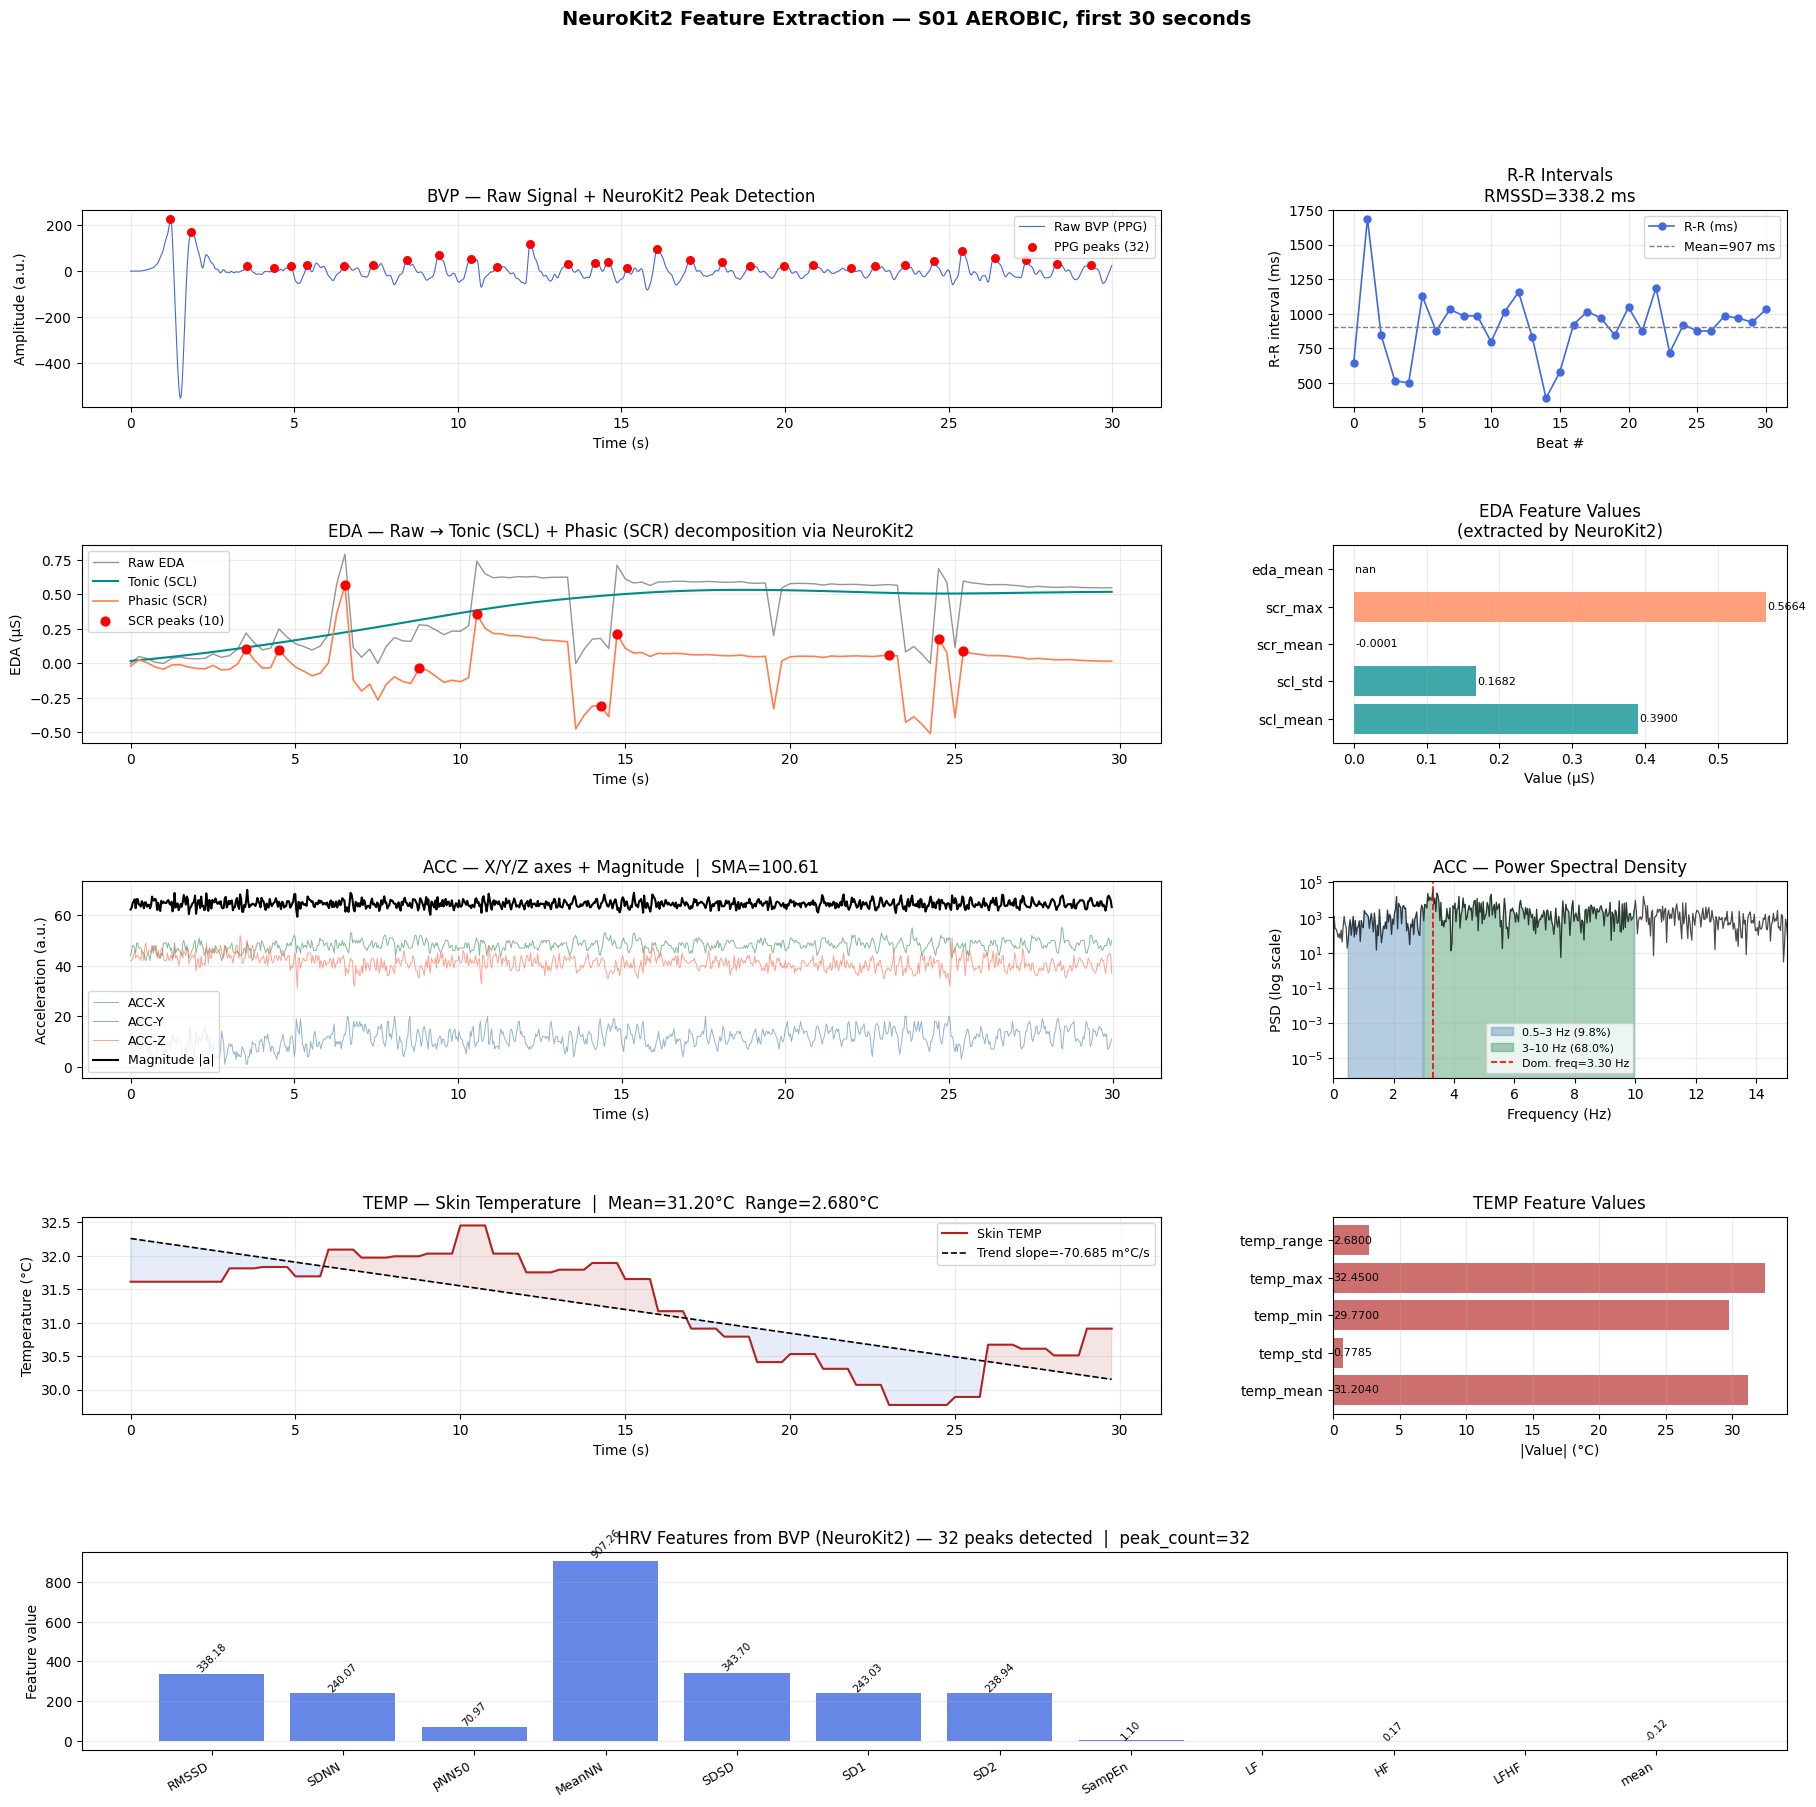

Saved → D:\Github\afc_lab\res\v12_base_all/neurokit2_feature_extraction_demo.png

All extracted features for this window (14 BVP features):
  bvp_HRV_RMSSD                  = 338.1769
  bvp_HRV_SDNN                   = 240.0675
  bvp_HRV_pNN50                  = 70.9677
  bvp_HRV_MeanNN                 = 907.2581
  bvp_HRV_SDSD                   = 343.7031
  bvp_HRV_SD1                    = 243.0348
  bvp_HRV_SD2                    = 238.9405
  bvp_HRV_SampEn                 = 1.0986
  bvp_HRV_LF                     = NaN
  bvp_HRV_HF                     = 0.1717
  bvp_HRV_LFHF                   = NaN
  bvp_peak_count                 = 32.0000
  bvp_mean                       = -0.1209
  bvp_std                        = 55.6785


In [37]:
# Cell 9 — NeuroKit2 feature extraction visualized on real data (S01 AEROBIC, first 30s)

DEMO_DIR = DATA_ROOT / 'ANAEROBIC' / 'S04'
demo_sess = load_subject_session(DEMO_DIR)

win_n   = int(WIN_SEC * FS['BVP'])   # 30s × 64 Hz = 1920 BVP samples
bvp_raw = demo_sess['bvp'][:win_n]
eda_raw = demo_sess['eda'][:int(WIN_SEC * FS['EDA'])]
acc_raw = demo_sess['acc'][:int(WIN_SEC * FS['ACC'])]
temp_raw= demo_sess['temp'][:int(WIN_SEC * FS['TEMP'])]

t_bvp  = np.arange(len(bvp_raw))  / FS['BVP']
t_eda  = np.arange(len(eda_raw))  / FS['EDA']
t_acc  = np.arange(len(acc_raw))  / FS['ACC']
t_temp = np.arange(len(temp_raw)) / FS['TEMP']

# ── Run NeuroKit2 pipelines ──────────────────────────────────────────────────
ppg_signals, ppg_info = nk.ppg_process(bvp_raw, sampling_rate=FS['BVP'])
eda_signals, eda_info = nk.eda_process(eda_raw, sampling_rate=FS['EDA'])

ppg_peaks = ppg_info.get('PPG_Peaks', np.array([], dtype=int))
rr_intervals = np.diff(ppg_peaks) / FS['BVP'] * 1000  # ms

hrv_time = nk.hrv_time(ppg_peaks, sampling_rate=FS['BVP'], show=False) if len(ppg_peaks) >= 4 else None
try:
    hrv_freq = nk.hrv_frequency(ppg_peaks, sampling_rate=FS['BVP'], show=False)
except Exception:
    hrv_freq = None

acc_mag = np.sqrt(acc_raw[:, 0]**2 + acc_raw[:, 1]**2 + acc_raw[:, 2]**2)
fft_mag = np.abs(np.fft.rfft(acc_mag - acc_mag.mean()))
freqs   = np.fft.rfftfreq(len(acc_mag), d=1.0 / FS['ACC'])
psd     = fft_mag ** 2

temp_slope = np.polyfit(t_temp, temp_raw, 1)
temp_trend = np.polyval(temp_slope, t_temp)

scr_peaks = eda_info.get('SCR_Peaks', np.array([], dtype=int))

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 20))
fig.suptitle(
    'NeuroKit2 Feature Extraction — S01 AEROBIC, first 30 seconds',
    fontsize=14, fontweight='bold', y=0.98,
)

# Subplot layout: 4 signal groups, each with 2 rows
# Row structure (9 subplots total):
gs = plt.GridSpec(5, 3, figure=fig, hspace=0.7, wspace=0.38)

# ── 1a. Raw BVP (PPG) + detected peaks ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(t_bvp, bvp_raw, color='royalblue', lw=0.8, label='Raw BVP (PPG)')
if len(ppg_peaks) > 0:
    ax1.scatter(ppg_peaks / FS['BVP'], bvp_raw[ppg_peaks],
                color='red', s=30, zorder=5, label=f'PPG peaks ({len(ppg_peaks)})')
ax1.set_title('BVP — Raw Signal + NeuroKit2 Peak Detection')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (a.u.)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# ── 1b. R-R intervals ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
if len(rr_intervals) > 0:
    ax2.plot(range(len(rr_intervals)), rr_intervals, 'o-',
             color='royalblue', ms=5, lw=1.2, label='R-R (ms)')
    ax2.axhline(rr_intervals.mean(), color='grey', linestyle='--', lw=1,
                label=f'Mean={rr_intervals.mean():.0f} ms')
    if hrv_time is not None:
        rmssd_val = hrv_time['HRV_RMSSD'].iloc[0] if 'HRV_RMSSD' in hrv_time else float('nan')
        ax2.set_title(f'R-R Intervals\nRMSSD={rmssd_val:.1f} ms')
    else:
        ax2.set_title('R-R Intervals')
    ax2.set_xlabel('Beat #')
    ax2.set_ylabel('R-R interval (ms)')
    ax2.legend(fontsize=9)
else:
    ax2.text(0.5, 0.5, 'Not enough peaks', ha='center', va='center')
    ax2.set_title('R-R Intervals')
ax2.grid(True, alpha=0.25)

# ── 2a. EDA raw + tonic + phasic ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
eda_tonic  = eda_signals.get('EDA_Tonic',  pd.Series(np.zeros(len(eda_raw))))
eda_phasic = eda_signals.get('EDA_Phasic', pd.Series(np.zeros(len(eda_raw))))
ax3.plot(t_eda, eda_raw,          color='dimgray',   lw=1.0, alpha=0.7, label='Raw EDA')
ax3.plot(t_eda, eda_tonic.values, color='darkcyan',  lw=1.5, label='Tonic (SCL)')
ax3.plot(t_eda, eda_phasic.values,color='coral',     lw=1.2, label='Phasic (SCR)')
if len(scr_peaks) > 0:
    valid_peaks = scr_peaks[scr_peaks < len(eda_raw)]
    ax3.scatter(valid_peaks / FS['EDA'], eda_phasic.values[valid_peaks],
                color='red', s=40, zorder=5, label=f'SCR peaks ({len(valid_peaks)})')
ax3.set_title('EDA — Raw → Tonic (SCL) + Phasic (SCR) decomposition via NeuroKit2')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('EDA (µS)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.25)

# ── 2b. EDA feature summary bar ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
eda_feats_demo = extract_eda_features(eda_raw, FS['EDA'])
feat_labels = ['scl_mean', 'scl_std', 'scr_mean', 'scr_max', 'eda_mean']
feat_vals   = [eda_feats_demo.get(f'eda_{k}', np.nan) for k in feat_labels]
colors_bar  = ['darkcyan', 'darkcyan', 'coral', 'coral', 'dimgray']
bars = ax4.barh(feat_labels, [v if not np.isnan(v) else 0 for v in feat_vals],
                color=colors_bar, alpha=0.75)
for bar, val in zip(bars, feat_vals):
    ax4.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=8)
ax4.set_title('EDA Feature Values\n(extracted by NeuroKit2)')
ax4.set_xlabel('Value (µS)')
ax4.grid(True, alpha=0.25, axis='x')

# ── 3a. ACC magnitude + per-axis ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(t_acc, acc_raw[:, 0], lw=0.7, alpha=0.6, color='steelblue', label='ACC-X')
ax5.plot(t_acc, acc_raw[:, 1], lw=0.7, alpha=0.6, color='seagreen',  label='ACC-Y')
ax5.plot(t_acc, acc_raw[:, 2], lw=0.7, alpha=0.6, color='tomato',    label='ACC-Z')
ax5.plot(t_acc, acc_mag,       lw=1.5, color='black', label='Magnitude |a|')
sma_val = np.mean(np.abs(acc_raw[:, 0]) + np.abs(acc_raw[:, 1]) + np.abs(acc_raw[:, 2]))
ax5.set_title(f'ACC — X/Y/Z axes + Magnitude  |  SMA={sma_val:.2f}')
ax5.set_xlabel('Time (s)')
ax5.set_ylabel('Acceleration (a.u.)')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.25)

# ── 3b. ACC power spectral density ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
total_psd = psd.sum() + 1e-9
band1 = ((freqs >= 0.5) & (freqs < 3))
band2 = ((freqs >= 3)   & (freqs < 10))
ax6.semilogy(freqs, psd, color='black', lw=0.9, alpha=0.7)
ax6.fill_between(freqs, psd, where=band1, color='steelblue',
                 alpha=0.4, label=f'0.5–3 Hz ({psd[band1].sum()/total_psd*100:.1f}%)')
ax6.fill_between(freqs, psd, where=band2, color='seagreen',
                 alpha=0.4, label=f'3–10 Hz ({psd[band2].sum()/total_psd*100:.1f}%)')
dom_freq = freqs[np.argmax(psd[1:]) + 1]
ax6.axvline(dom_freq, color='red', linestyle='--', lw=1.2,
            label=f'Dom. freq={dom_freq:.2f} Hz')
ax6.set_xlim(0, 15)
ax6.set_title('ACC — Power Spectral Density')
ax6.set_xlabel('Frequency (Hz)')
ax6.set_ylabel('PSD (log scale)')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.25)

# ── 4a. TEMP signal + linear trend ───────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, :2])
ax7.plot(t_temp, temp_raw, color='firebrick', lw=1.5, label='Skin TEMP')
ax7.plot(t_temp, temp_trend, 'k--', lw=1.2,
         label=f'Trend slope={temp_slope[0]*1000:.3f} m°C/s')
ax7.fill_between(t_temp, temp_raw, temp_trend,
                 where=(temp_raw >= temp_trend), alpha=0.12, color='firebrick')
ax7.fill_between(t_temp, temp_raw, temp_trend,
                 where=(temp_raw < temp_trend),  alpha=0.12, color='royalblue')
ax7.set_title(
    f'TEMP — Skin Temperature  |  Mean={temp_raw.mean():.2f}°C  '
    f'Range={temp_raw.max()-temp_raw.min():.3f}°C')
ax7.set_xlabel('Time (s)')
ax7.set_ylabel('Temperature (°C)')
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.25)

# ── 4b. TEMP feature summary bar ─────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 2])
temp_feats_demo = extract_temp_features(temp_raw)
tf_labels = ['temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_range']
tf_vals   = [temp_feats_demo.get(k, np.nan) for k in tf_labels]
ax8.barh(tf_labels, [abs(v) if not np.isnan(v) else 0 for v in tf_vals],
         color='firebrick', alpha=0.65)
for i, val in enumerate(tf_vals):
    ax8.text(0.002, i, f'{val:.4f}', va='center', fontsize=8)
ax8.set_title('TEMP Feature Values')
ax8.set_xlabel('|Value| (°C)')
ax8.grid(True, alpha=0.25, axis='x')

# ── 5. HRV freq summary bar (if available) ───────────────────────────────────
ax9 = fig.add_subplot(gs[4, :])
bvp_feats_demo = extract_bvp_features(bvp_raw, FS['BVP'])
hrv_feat_names = [
    'bvp_HRV_RMSSD', 'bvp_HRV_SDNN', 'bvp_HRV_pNN50',
    'bvp_HRV_MeanNN', 'bvp_HRV_SD1', 'bvp_HRV_SD2',
    'bvp_HRV_LF', 'bvp_HRV_HF', 'bvp_HRV_LFHF',
    'bvp_bvp_mean', 'bvp_bvp_std', 'bvp_peak_count',
]
# Use all bvp feature keys
feat_keys = [k for k in bvp_feats_demo if k != 'bvp_peak_count']
feat_keys_display = feat_keys[:12]
feat_vals_bvp = [bvp_feats_demo.get(k, np.nan) for k in feat_keys_display]
valid_mask = [not np.isnan(v) for v in feat_vals_bvp]
x_pos = np.arange(len(feat_keys_display))
bars9 = ax9.bar(
    x_pos,
    [v if not np.isnan(v) else 0 for v in feat_vals_bvp],
    color=['royalblue' if m else 'lightgrey' for m in valid_mask],
    alpha=0.8,
)
ax9.set_xticks(x_pos)
ax9.set_xticklabels(
    [k.replace('bvp_', '').replace('HRV_', '') for k in feat_keys_display],
    rotation=30, ha='right', fontsize=9,
)
for bar, val in zip(bars9, feat_vals_bvp):
    if not np.isnan(val):
        ax9.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bar.get_height() * 0.02,
                 f'{val:.2f}', ha='center', fontsize=7.5, rotation=45)
ax9.set_title(
    f'HRV Features from BVP (NeuroKit2) — '
    f'{len(ppg_peaks)} peaks detected  |  '
    f'peak_count={bvp_feats_demo.get("bvp_peak_count", "?")}',
)
ax9.set_ylabel('Feature value')
ax9.grid(True, alpha=0.25, axis='y')

plt.savefig(RESULTS_DIR / 'neurokit2_feature_extraction_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/neurokit2_feature_extraction_demo.png')
print(f'\nAll extracted features for this window ({len(bvp_feats_demo)} BVP features):')
for k, v in bvp_feats_demo.items():
    print(f'  {k:<30} = {v:.4f}' if not np.isnan(v) else f'  {k:<30} = NaN')


## 3. Dataset Construction

Строим датасет: загружаем все сессии AEROBIC + ANAEROBIC, нарезаем окнами 30с / hop 5с, для каждого окна извлекаем фичи и присваиваем метку усталости (last 50% = fatigue).

In [22]:
# Cell 10 — Build dataset

def get_subject_list(activity: str) -> list:
    """List subject folders for given activity (AEROBIC / ANAEROBIC)."""
    act_dir = DATA_ROOT / activity
    folders = []
    for d in sorted(act_dir.iterdir()):
        if not d.is_dir():
            continue
        # Handle split sessions (S11_a, S11_b → treat as S11)
        base = d.name.split('_')[0]
        if base in EXCLUDE.get(activity, set()):
            continue
        folders.append(d)
    return folders


all_rows = []

for activity in ['AEROBIC', 'ANAEROBIC']:
    subj_dirs = get_subject_list(activity)
    print(f'\n=== {activity}: {len(subj_dirs)} subject sessions ===')

    for subj_dir in tqdm(subj_dirs, desc=activity):
        # Normalize subject ID (strip _a, _b suffixes)
        subj_id = f"{activity}_{subj_dir.name.split('_')[0]}"

        sess = load_subject_session(subj_dir)
        if sess is None:
            print(f'  SKIP {subj_dir.name}: load error')
            continue

        n_bvp = len(sess['bvp'])
        win_n = int(WIN_SEC * FS['BVP'])
        hop_n = int(HOP_SEC * FS['BVP'])

        if n_bvp < win_n:
            print(f'  SKIP {subj_dir.name}: too short ({n_bvp} < {win_n} BVP samples)')
            continue

        # Sliding window with fatigue labeling
        fatigue_threshold = int(n_bvp * FATIGUE_RATIO)

        for start in range(0, n_bvp - win_n + 1, hop_n):
            end = start + win_n

            # Fatigue label: window midpoint past 50% of session
            mid = (start + end) // 2
            label = 1 if mid >= fatigue_threshold else 0

            feats = extract_window_features(sess, start, end)
            feats['subject_id']  = subj_id
            feats['activity']    = activity
            feats['label']       = label
            feats['win_start']   = start
            all_rows.append(feats)

df = pd.DataFrame(all_rows)
print(f'\nTotal windows: {len(df)}')
print(f'Subjects:      {df["subject_id"].nunique()}')
print(f'Class balance: {df["label"].value_counts().to_dict()}')
print(f'Features:      {len(df.columns) - 4}  (excl. subject_id, activity, label, win_start)')


=== AEROBIC: 31 subject sessions ===


AEROBIC:   0%|          | 0/31 [00:00<?, ?it/s]


=== ANAEROBIC: 32 subject sessions ===


ANAEROBIC:   0%|          | 0/32 [00:00<?, ?it/s]


Total windows: 22835
Subjects:      61
Class balance: {0: 13749, 1: 9086}
Features:      48  (excl. subject_id, activity, label, win_start)


In [23]:
# Cell 11 — NaN handling + save
meta_cols = ['subject_id', 'activity', 'label', 'win_start']
feature_cols = [c for c in df.columns if c not in meta_cols]

# NaN stats
nan_frac = df[feature_cols].isna().mean().sort_values(ascending=False)
print('Top-10 features by NaN fraction:')
print(nan_frac.head(10).to_string())

# Drop features with >50% NaN
drop_cols = nan_frac[nan_frac > 0.5].index.tolist()
print(f'\nDropping {len(drop_cols)} features with >50% NaN: {drop_cols}')
df.drop(columns=drop_cols, inplace=True)
feature_cols = [c for c in df.columns if c not in meta_cols]

# Impute remaining NaN with per-feature median
for col in feature_cols:
    med = df[col].median()
    df[col].fillna(med, inplace=True)

print(f'\nFinal feature count: {len(feature_cols)}')
print(f'Remaining NaN: {df[feature_cols].isna().sum().sum()}')

# Save
df.to_parquet(RESULTS_DIR / 'features_v11.parquet', index=False)
print(f'Saved → {RESULTS_DIR}/features_v11.parquet')

Top-10 features by NaN fraction:
bvp_HRV_LFHF         1.000000
bvp_HRV_LF           1.000000
bvp_HRV_HF           0.002190
eda_scr_amplitude    0.001095
bvp_HRV_SampEn       0.001051
bvp_HRV_MeanNN       0.000788
bvp_HRV_pNN50        0.000788
bvp_HRV_RMSSD        0.000788
bvp_HRV_SD2          0.000788
bvp_HRV_SD1          0.000788

Dropping 2 features with >50% NaN: ['bvp_HRV_LFHF', 'bvp_HRV_LF']

Final feature count: 46
Remaining NaN: 0
Saved → D:\Github\afc_lab\res\v12_base_all/features_v11.parquet


## 4. Train / Val / Test Split

Subject-level split (70 / 15 / 15%) — тот же подход, что в CNN v8c для честного сравнения.

In [24]:
# Cell 13 — Subject-level split
subjects = df['subject_id'].unique()
np.random.seed(SEED)
np.random.shuffle(subjects)

n_total = len(subjects)
n_test  = max(1, int(n_total * TEST_RATIO))
n_val   = max(1, int(n_total * VAL_RATIO))
n_train = n_total - n_val - n_test

train_subjects = subjects[:n_train]
val_subjects   = subjects[n_train:n_train + n_val]
test_subjects  = subjects[n_train + n_val:]

train_idx = df['subject_id'].isin(train_subjects)
val_idx   = df['subject_id'].isin(val_subjects)
test_idx  = df['subject_id'].isin(test_subjects)

X_train = df.loc[train_idx, feature_cols].values
y_train = df.loc[train_idx, 'label'].values
X_val   = df.loc[val_idx,   feature_cols].values
y_val   = df.loc[val_idx,   'label'].values
X_test  = df.loc[test_idx,  feature_cols].values
y_test  = df.loc[test_idx,  'label'].values

def sanitize_xy(X, y, split_name: str):
    """Keep only rows with finite feature values while preserving X/y alignment."""
    row_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    removed = int((~row_mask).sum())
    if removed > 0:
        print(f'{split_name}: removed {removed} rows with NaN/Inf features')
    X_clean = X[row_mask]
    y_clean = y[row_mask].astype(int)
    if len(y_clean) == 0:
        raise ValueError(f'{split_name}: no samples left after cleaning')
    return X_clean, y_clean

X_train, y_train = sanitize_xy(X_train, y_train, 'Train')
X_val, y_val     = sanitize_xy(X_val, y_val, 'Val')
X_test, y_test   = sanitize_xy(X_test, y_test, 'Test')

# Standardize features (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Subjects total: {n_total}  (train={n_train}, val={n_val}, test={n_test})')
print(f'Train windows:  {len(y_train):5d}  (pos={y_train.sum()}, neg={(y_train==0).sum()})')
print(f'Val windows:    {len(y_val):5d}  (pos={y_val.sum()},   neg={(y_val==0).sum()})')
print(f'Test windows:   {len(y_test):5d}  (pos={y_test.sum()},  neg={(y_test==0).sum()})')

Train: removed 1391 rows with NaN/Inf features
Val: removed 334 rows with NaN/Inf features
Test: removed 395 rows with NaN/Inf features
Subjects total: 61  (train=43, val=9, test=9)
Train windows:  14281  (pos=5929, neg=8352)
Val windows:     3487  (pos=1438,   neg=2049)
Test windows:    2947  (pos=1243,  neg=1704)


## 5. Baseline Models Training

Обучаем все базовые алгоритмы на одних и тех же NeuroKit2-признаках.  
Общий протокол: `class_weight='balanced'` (или `sample_weight`) везде, StandardScaler из Cell 13.

| Алгоритм | Ключевые гиперпараметры |
|----------|------------------------|
| **Logistic Regression** | C=1.0, solver=lbfgs, max_iter=2000 |
| **Random Forest** | n_estimators=300, min_samples_leaf=5 |
| **Extra Trees** | n_estimators=300, min_samples_leaf=5 |
| **Gradient Boosting** | n_estimators=300, depth=4, lr=0.05 |
| **XGBoost** | n_estimators=500, depth=5, lr=0.05, L1+L2 |


In [25]:
# Cell 15 — Train all baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)
from sklearn.utils.class_weight import compute_sample_weight

MODELS = {}        # name → fitted model
VAL_PROBS = {}     # name → val probabilities

# ── 1. Logistic Regression ──────────────────────────────────────────────────
print('Training Logistic Regression...')
lr = LogisticRegression(
    C=1.0, max_iter=2000, class_weight='balanced',
    solver='lbfgs', random_state=SEED, n_jobs=-1,
)
lr.fit(X_train, y_train)
MODELS['LogReg'] = lr

# ── 2. Random Forest ────────────────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    class_weight='balanced', oob_score=True,
    random_state=SEED, n_jobs=-1,
)
rf.fit(X_train, y_train)
MODELS['RandomForest'] = rf

# ── 3. Extra Trees ──────────────────────────────────────────────────────────
print('Training Extra Trees...')
et = ExtraTreesClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    class_weight='balanced', oob_score=True, bootstrap=True,
    random_state=SEED, n_jobs=-1,
)
et.fit(X_train, y_train)
MODELS['ExtraTrees'] = et

# ── 4. Gradient Boosting (sklearn) ──────────────────────────────────────────
print('Training Gradient Boosting (sklearn)...')
sample_weights_gb = compute_sample_weight('balanced', y_train)
gb = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED,
)
gb.fit(X_train, y_train, sample_weight=sample_weights_gb)
MODELS['GradBoost'] = gb

# ── 5. XGBoost ──────────────────────────────────────────────────────────────
print('Training XGBoost...')
sample_weights = compute_sample_weight('balanced', y_train)
XGB_PARAMS = dict(
    n_estimators      = 500,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       = 'logloss',
    random_state      = SEED,
    n_jobs            = -1,
    tree_method       = 'hist',
)
xgb_model = xgb.XGBClassifier(**XGB_PARAMS)
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)
MODELS['XGBoost'] = xgb_model
model = xgb_model  # backward-compat alias

# ── Validation summary ───────────────────────────────────────────────────────
print(f'\n{"=" * 60}')
print(f'{"VALIDATION METRICS (threshold=0.5)":^60}')
print(f'{"=" * 60}')
print(f'{"Model":<20} {"F1-macro":>10} {"ROC-AUC":>10}')
print('-' * 42)
for name, m in MODELS.items():
    probs = m.predict_proba(X_val)[:, 1]
    f1  = f1_score(y_val, (probs >= 0.5).astype(int), average='macro', zero_division=0)
    auc = roc_auc_score(y_val, probs)
    VAL_PROBS[name] = probs
    print(f'  {name:<18} {f1:>10.4f} {auc:>10.4f}')


Training Logistic Regression...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting (sklearn)...
Training XGBoost...
[0]	validation_0-logloss:0.67024	validation_1-logloss:0.67318
[100]	validation_0-logloss:0.21107	validation_1-logloss:0.45987
[200]	validation_0-logloss:0.13075	validation_1-logloss:0.47989
[300]	validation_0-logloss:0.08905	validation_1-logloss:0.51511
[400]	validation_0-logloss:0.06411	validation_1-logloss:0.53744
[499]	validation_0-logloss:0.04707	validation_1-logloss:0.56498

             VALIDATION METRICS (threshold=0.5)             
Model                  F1-macro    ROC-AUC
------------------------------------------
  LogReg                 0.7282     0.7945
  RandomForest           0.7552     0.8417
  ExtraTrees             0.7432     0.8344
  GradBoost              0.7730     0.8517
  XGBoost                0.7729     0.8501


In [26]:
# Cell 16 — Find val-optimal threshold for every model
def find_best_threshold(labels, probs, n_thresholds=200):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, n_thresholds):
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


THRESHOLDS = {}
print(f'{"Model":<20} {"Opt threshold":>15} {"Val F1 @ opt-thr":>18}')
print('-' * 55)
for name, probs in VAL_PROBS.items():
    t, f1 = find_best_threshold(y_val, probs)
    THRESHOLDS[name] = t
    print(f'  {name:<18} {t:>15.3f} {f1:>18.4f}')

# Backward-compat alias for XGBoost
best_thresh = THRESHOLDS['XGBoost']
val_probs   = VAL_PROBS['XGBoost']

# Save XGBoost model
import joblib
joblib.dump(MODELS['XGBoost'], RESULTS_DIR / 'xgb_model_v11.pkl')
joblib.dump(scaler, RESULTS_DIR / 'scaler_v11.pkl')
print(f'\nXGBoost model saved → {RESULTS_DIR}')


Model                  Opt threshold   Val F1 @ opt-thr
-------------------------------------------------------
  LogReg                       0.570             0.7397
  RandomForest                 0.402             0.7608
  ExtraTrees                   0.486             0.7446
  GradBoost                    0.494             0.7741
  XGBoost                      0.510             0.7751

XGBoost model saved → D:\Github\afc_lab\res\v12_base_all


## 5.1 Training Dynamics (Learning Curves)

Визуализируем процесс обучения каждой модели:
- **XGBoost** — train/val log-loss по итерациям бустинга
- **Gradient Boosting** — train/val deviance по итерациям
- **Random Forest / Extra Trees** — OOB accuracy vs n_estimators (out-of-bag оценка на данных, не попавших в бутстреп-выборку)
- **Logistic Regression** — learning curve: F1-macro vs размер обучающей выборки (5-fold CV)


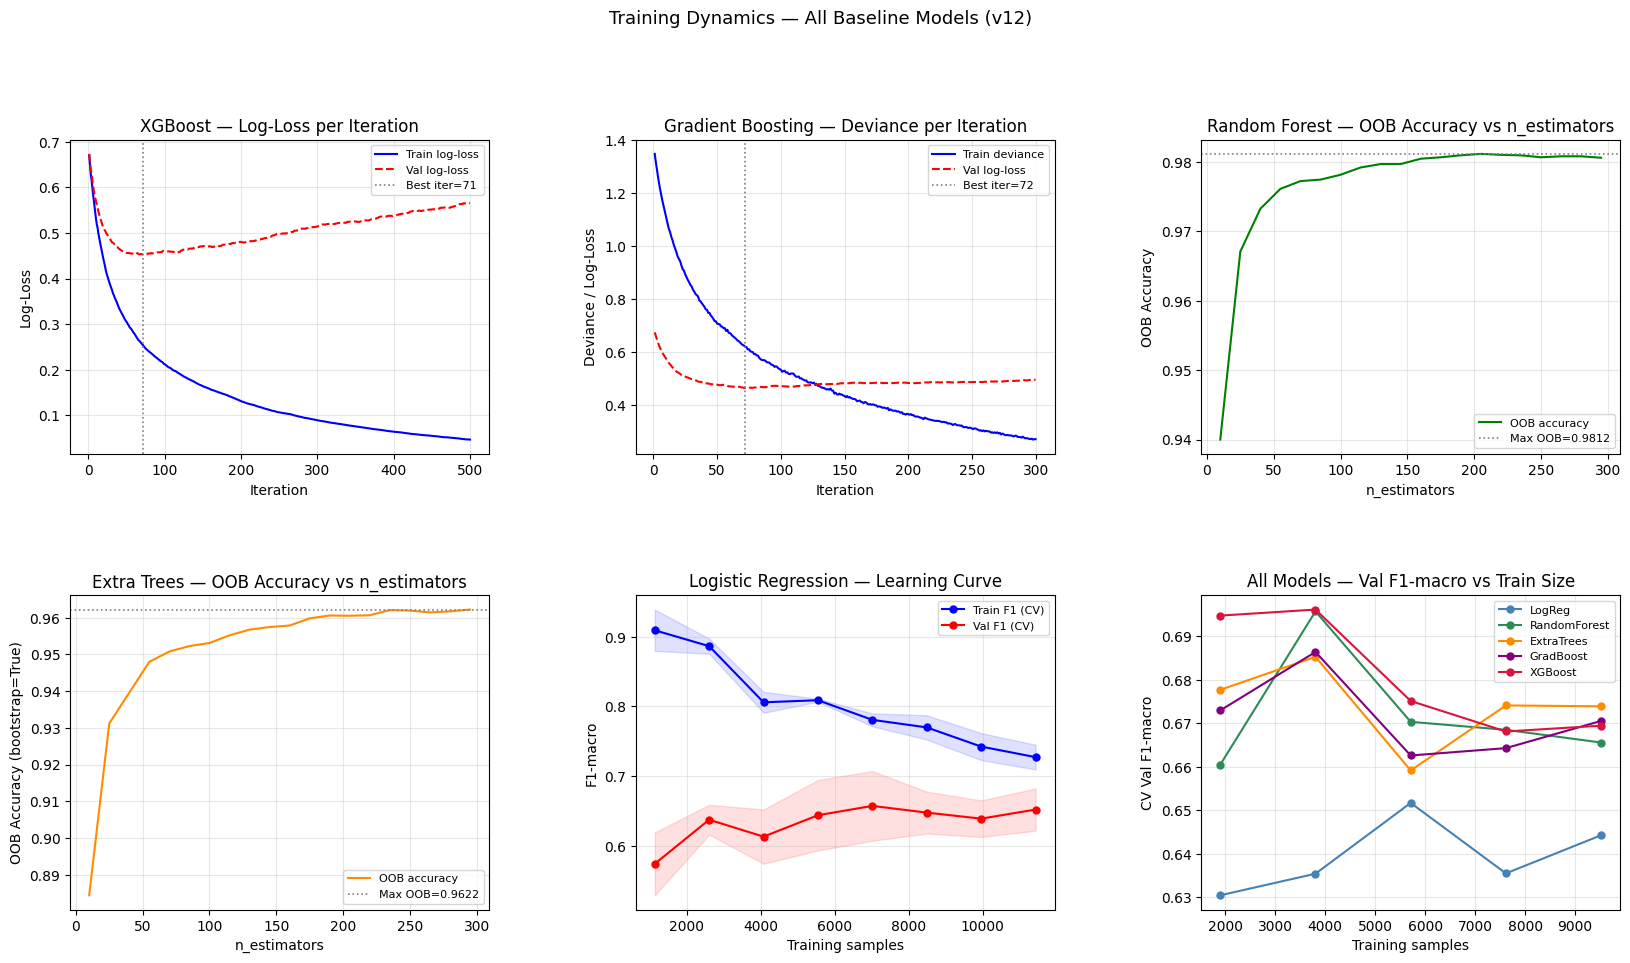

Saved → D:\Github\afc_lab\res\v12_base_all/training_curves_v12.png


In [27]:
# Cell 17 — Training dynamics: one subplot per model
from sklearn.model_selection import learning_curve as sk_learning_curve
from sklearn.metrics import log_loss
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. XGBoost: train + val logloss per iteration ───────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
xgb_res  = MODELS['XGBoost'].evals_result()
xgb_train_ll = xgb_res['validation_0']['logloss']
xgb_val_ll   = xgb_res['validation_1']['logloss']
iters = range(1, len(xgb_train_ll) + 1)
ax1.plot(iters, xgb_train_ll, 'b-',  lw=1.5, label='Train log-loss')
ax1.plot(iters, xgb_val_ll,   'r--', lw=1.5, label='Val log-loss')
best_iter = int(np.argmin(xgb_val_ll)) + 1
ax1.axvline(best_iter, color='grey', linestyle=':', lw=1.2,
            label=f'Best iter={best_iter}')
ax1.set_title('XGBoost — Log-Loss per Iteration')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Log-Loss')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── 2. Gradient Boosting: train deviance + val deviance per stage ────────────
ax2 = fig.add_subplot(gs[0, 1])
gb_train_dev = MODELS['GradBoost'].train_score_
n_stages = len(gb_train_dev)
gb_val_dev = [
    log_loss(y_val, p) for p in MODELS['GradBoost'].staged_predict_proba(X_val)
]
stages = range(1, n_stages + 1)
ax2.plot(stages, gb_train_dev, 'b-',  lw=1.5, label='Train deviance')
ax2.plot(stages, gb_val_dev,   'r--', lw=1.5, label='Val log-loss')
best_gb = int(np.argmin(gb_val_dev)) + 1
ax2.axvline(best_gb, color='grey', linestyle=':', lw=1.2,
            label=f'Best iter={best_gb}')
ax2.set_title('Gradient Boosting — Deviance per Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Deviance / Log-Loss')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. Random Forest: OOB accuracy vs n_estimators ──────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
estimator_range = list(range(10, 310, 15))
rf_oob = RandomForestClassifier(
    max_depth=None, min_samples_leaf=5, class_weight='balanced',
    oob_score=True, warm_start=True, random_state=SEED, n_jobs=-1,
)
oob_rf = []
for n in estimator_range:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train, y_train)
    oob_rf.append(rf_oob.oob_score_)
ax3.plot(estimator_range, oob_rf, 'g-', lw=1.5, label='OOB accuracy')
ax3.axhline(max(oob_rf), color='grey', linestyle=':', lw=1.2,
            label=f'Max OOB={max(oob_rf):.4f}')
ax3.set_title('Random Forest — OOB Accuracy vs n_estimators')
ax3.set_xlabel('n_estimators')
ax3.set_ylabel('OOB Accuracy')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ── 4. Extra Trees: OOB accuracy vs n_estimators ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
et_oob = ExtraTreesClassifier(
    max_depth=None, min_samples_leaf=5, class_weight='balanced',
    oob_score=True, bootstrap=True, warm_start=True,
    random_state=SEED, n_jobs=-1,
)
oob_et = []
for n in estimator_range:
    et_oob.set_params(n_estimators=n)
    et_oob.fit(X_train, y_train)
    oob_et.append(et_oob.oob_score_)
ax4.plot(estimator_range, oob_et, color='darkorange', lw=1.5, label='OOB accuracy')
ax4.axhline(max(oob_et), color='grey', linestyle=':', lw=1.2,
            label=f'Max OOB={max(oob_et):.4f}')
ax4.set_title('Extra Trees — OOB Accuracy vs n_estimators')
ax4.set_xlabel('n_estimators')
ax4.set_ylabel('OOB Accuracy (bootstrap=True)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# ── 5. Logistic Regression: learning curve (train size vs F1) ───────────────
ax5 = fig.add_subplot(gs[1, 1])
lr_lc = LogisticRegression(
    C=1.0, max_iter=2000, class_weight='balanced',
    solver='lbfgs', random_state=SEED, n_jobs=-1,
)
train_sizes, tr_scores, val_scores = sk_learning_curve(
    lr_lc, X_train, y_train,
    cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)
ax5.fill_between(train_sizes,
                 tr_scores.mean(1) - tr_scores.std(1),
                 tr_scores.mean(1) + tr_scores.std(1), alpha=0.12, color='b')
ax5.fill_between(train_sizes,
                 val_scores.mean(1) - val_scores.std(1),
                 val_scores.mean(1) + val_scores.std(1), alpha=0.12, color='r')
ax5.plot(train_sizes, tr_scores.mean(1),  'b-o', lw=1.5, ms=5, label='Train F1 (CV)')
ax5.plot(train_sizes, val_scores.mean(1), 'r-o', lw=1.5, ms=5, label='Val F1 (CV)')
ax5.set_title('Logistic Regression — Learning Curve')
ax5.set_xlabel('Training samples')
ax5.set_ylabel('F1-macro')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ── 6. Summary: val F1 vs train size for all models ────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
PALETTE_LC = {
    'LogReg': 'steelblue',
    'RandomForest': 'seagreen',
    'ExtraTrees': 'darkorange',
    'GradBoost': 'purple',
    'XGBoost': 'crimson',
}
for m_name, m_color in PALETTE_LC.items():
    m_obj = MODELS[m_name]
    sizes, _, val_sc = sk_learning_curve(
        m_obj, X_train, y_train,
        cv=3, scoring='f1_macro',
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
    )
    ax6.plot(sizes, val_sc.mean(1), color=m_color, lw=1.5,
             marker='o', ms=5, label=m_name)
ax6.set_title('All Models — Val F1-macro vs Train Size')
ax6.set_xlabel('Training samples')
ax6.set_ylabel('CV Val F1-macro')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.suptitle('Training Dynamics — All Baseline Models (v12)', fontsize=13, y=1.01)
plt.savefig(RESULTS_DIR / 'training_curves_v12.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/training_curves_v12.png')


## 6. Test Evaluation

In [28]:
# Cell 18 — Test evaluation for all models
TEST_RESULTS = {}

print('=' * 75)
print(f'{"TEST RESULTS — All Baseline Models":^75}')
print('=' * 75)
print(f'{"Model":<20} {"F1-macro":>10} {"ROC-AUC":>10} {"PR-AUC":>10} {"BalAcc":>10}')
print('-' * 64)

for name, m in MODELS.items():
    probs  = m.predict_proba(X_test)[:, 1]
    thresh = THRESHOLDS[name]
    preds  = (probs >= thresh).astype(int)

    f1_vt  = f1_score(y_test, preds, average='macro', zero_division=0)
    auc_v  = roc_auc_score(y_test, probs)
    prauc  = average_precision_score(y_test, probs)
    balacc = balanced_accuracy_score(y_test, preds)
    _, f1_opt = find_best_threshold(y_test, probs)

    TEST_RESULTS[name] = dict(
        probs=probs, preds=preds, thresh=thresh,
        f1_vt=f1_vt, auc=auc_v, prauc=prauc,
        balacc=balacc, f1_opt=f1_opt,
    )
    print(f'  {name:<18} {f1_vt:>10.4f} {auc_v:>10.4f} {prauc:>10.4f} {balacc:>10.4f}')

# ── Detailed classification report for XGBoost ──
print(f'\n{"─"*50}')
print('Detailed report — XGBoost:')
print(classification_report(
    y_test, TEST_RESULTS['XGBoost']['preds'],
    target_names=['Normal', 'Fatigue'], zero_division=0,
))

# ── Backward-compat aliases ──────────────────────────────────────────────────
test_probs    = TEST_RESULTS['XGBoost']['probs']
test_preds_vt = TEST_RESULTS['XGBoost']['preds']
test_f1_vt    = TEST_RESULTS['XGBoost']['f1_vt']
test_auc      = TEST_RESULTS['XGBoost']['auc']
test_prauc    = TEST_RESULTS['XGBoost']['prauc']
test_balacc   = TEST_RESULTS['XGBoost']['balacc']
test_f1_opt   = TEST_RESULTS['XGBoost']['f1_opt']
test_thresh_opt = THRESHOLDS['XGBoost']

# ── Save all results ─────────────────────────────────────────────────────────
rows = [
    dict(
        model=name,
        val_threshold=r['thresh'],
        test_f1_val_thr=r['f1_vt'],
        test_f1_opt_thr=r['f1_opt'],
        test_roc_auc=r['auc'],
        test_pr_auc=r['prauc'],
        test_balanced_acc=r['balacc'],
        n_features=len(feature_cols),
        win_sec=WIN_SEC,
        hop_sec=HOP_SEC,
    )
    for name, r in TEST_RESULTS.items()
]
pd.DataFrame(rows).to_csv(RESULTS_DIR / 'test_results_v11.csv', index=False)
print(f'All results saved → {RESULTS_DIR}/test_results_v11.csv')


                    TEST RESULTS — All Baseline Models                     
Model                  F1-macro    ROC-AUC     PR-AUC     BalAcc
----------------------------------------------------------------
  LogReg                 0.6396     0.7570     0.6535     0.6422
  RandomForest           0.7706     0.8318     0.7385     0.7889
  ExtraTrees             0.7620     0.8603     0.7722     0.7651
  GradBoost              0.7536     0.8341     0.7354     0.7600
  XGBoost                0.7522     0.8476     0.7832     0.7570

──────────────────────────────────────────────────
Detailed report — XGBoost:
              precision    recall  f1-score   support

      Normal       0.82      0.74      0.78      1704
     Fatigue       0.69      0.77      0.73      1243

    accuracy                           0.76      2947
   macro avg       0.75      0.76      0.75      2947
weighted avg       0.76      0.76      0.76      2947

All results saved → D:\Github\afc_lab\res\v12_base_all/test_res

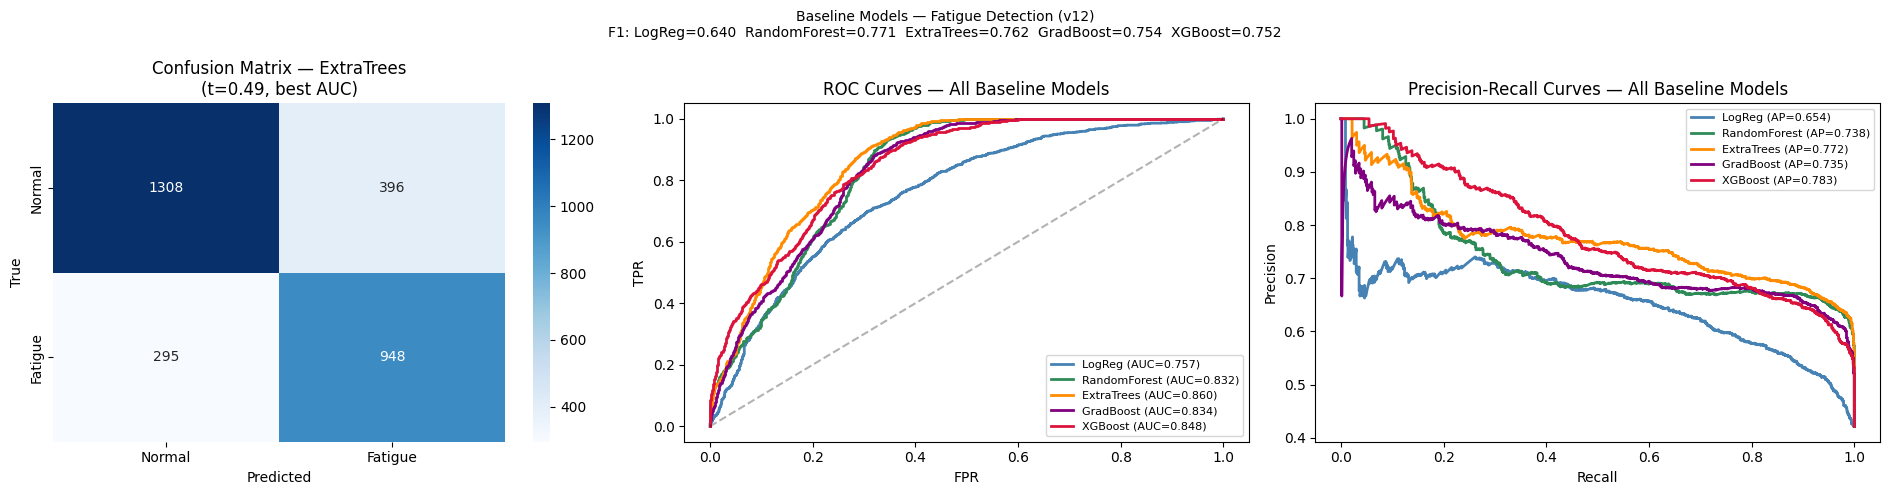

In [29]:
# Cell 19 — Plots: ROC/PR curves for all models + confusion matrix for best model
PALETTE = ['steelblue', 'seagreen', 'darkorange', 'purple', 'crimson']
model_names = list(TEST_RESULTS.keys())

# Best model by test ROC-AUC
best_name = max(TEST_RESULTS, key=lambda k: TEST_RESULTS[k]['auc'])

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# ── Confusion matrix for best model ──────────────────────────────────────────
cm = confusion_matrix(y_test, TEST_RESULTS[best_name]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fatigue'], yticklabels=['Normal', 'Fatigue'])
axes[0].set_title(
    f'Confusion Matrix — {best_name}\n(t={TEST_RESULTS[best_name]["thresh"]:.2f}, best AUC)')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# ── ROC curves — all models ──────────────────────────────────────────────────
for name, c in zip(model_names, PALETTE):
    r = TEST_RESULTS[name]
    fpr, tpr, _ = roc_curve(y_test, r['probs'])
    axes[1].plot(fpr, tpr, color=c, lw=2, label=f"{name} (AUC={r['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curves — All Baseline Models')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

# ── PR curves — all models ───────────────────────────────────────────────────
for name, c in zip(model_names, PALETTE):
    r = TEST_RESULTS[name]
    pr_v, rc_v, _ = precision_recall_curve(y_test, r['probs'])
    axes[2].plot(rc_v, pr_v, color=c, lw=2, label=f"{name} (AP={r['prauc']:.3f})")
axes[2].set_title('Precision-Recall Curves — All Baseline Models')
axes[2].legend(fontsize=8, loc='upper right')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

f1_row = '  '.join(f"{n}={TEST_RESULTS[n]['f1_vt']:.3f}" for n in model_names)
plt.suptitle(f'Baseline Models — Fatigue Detection (v12)\nF1: {f1_row}', fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_results_v11.png', dpi=150)
plt.show()


## 7. LOSO Evaluation

Leave-One-Subject-Out — честная оценка обобщения, аналогичная нашему CNN-pipeline.

In [30]:
# Cell 21 — LOSO evaluation: XGBoost + Random Forest
# (GradBoost/ExtraTrees omitted from LOSO — training time; compare top-2 approaches)

def loso_eval(
    df: pd.DataFrame,
    feature_cols: list,
    model_name: str,
    build_model_fn,
    n_folds: int = 20,
) -> pd.DataFrame:
    """Leave-One-Subject-Out evaluation for a given sklearn-compatible model factory."""
    unique_subj = df['subject_id'].unique()

    valid = [
        s for s in unique_subj
        if len(df[df['subject_id'] == s]['label'].unique()) >= 2
        and len(df[df['subject_id'] == s]) >= 20
    ]
    print(f'[{model_name}] Valid LOSO subjects: {len(valid)} / {len(unique_subj)}')

    if len(valid) > n_folds:
        np.random.seed(SEED)
        valid = list(np.random.choice(valid, n_folds, replace=False))

    def _clean(X, y):
        X_arr = np.asarray(X, dtype=np.float64)
        y_arr = np.asarray(y, dtype=int)
        mask = np.isfinite(X_arr).all(axis=1) & np.isfinite(y_arr)
        return X_arr[mask], y_arr[mask], int((~mask).sum())

    results = []
    for subj in tqdm(valid, desc=f'LOSO {model_name}'):
        tr_mask = df['subject_id'] != subj
        te_mask = df['subject_id'] == subj

        X_tr, y_tr, rtr = _clean(df.loc[tr_mask, feature_cols].values,
                                  df.loc[tr_mask, 'label'].values)
        X_te, y_te, rte = _clean(df.loc[te_mask, feature_cols].values,
                                  df.loc[te_mask, 'label'].values)

        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            continue
        if len(y_tr) < 20 or len(y_te) < 5:
            continue

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        m = build_model_fn()
        sw = compute_sample_weight('balanced', y_tr)
        m.fit(X_tr, y_tr, sample_weight=sw)

        probs = m.predict_proba(X_te)[:, 1]
        preds = (probs >= 0.5).astype(int)
        try:
            auc_val = roc_auc_score(y_te, probs)
        except Exception:
            auc_val = float('nan')

        results.append(dict(
            subject=subj,
            n_samples=int(len(y_te)),
            f1_macro=f1_score(y_te, preds, average='macro', zero_division=0),
            roc_auc=auc_val,
        ))

    return pd.DataFrame(results)


# ── XGBoost LOSO ─────────────────────────────────────────────────────────────
def _build_xgb():
    return xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=SEED,
        n_jobs=-1, tree_method='hist',
    )

loso_xgb_df = loso_eval(df, feature_cols, 'XGBoost', _build_xgb, n_folds=15)

# ── Random Forest LOSO ───────────────────────────────────────────────────────
def _build_rf():
    return RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=5,
        class_weight='balanced', random_state=SEED, n_jobs=-1,
    )

loso_rf_df = loso_eval(df, feature_cols, 'RandomForest', _build_rf, n_folds=15)

# ── Summary ──────────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('LOSO SUMMARY')
print('=' * 65)
for label, loso_df_cur in [('XGBoost', loso_xgb_df), ('RandomForest', loso_rf_df)]:
    f1_mean = loso_df_cur['f1_macro'].mean()
    f1_std  = loso_df_cur['f1_macro'].std()
    auc_mean = loso_df_cur['roc_auc'].mean(skipna=True)
    auc_std  = loso_df_cur['roc_auc'].std(skipna=True)
    print(f'  {label:<16}  F1={f1_mean:.4f}±{f1_std:.4f}  AUC={auc_mean:.4f}±{auc_std:.4f}')

# Use XGBoost LOSO as primary result (backward-compat)
loso_df = loso_xgb_df

# Save both
loso_xgb_df.to_csv(RESULTS_DIR / 'loso_results_v11_xgb.csv', index=False)
loso_rf_df.to_csv(RESULTS_DIR / 'loso_results_v11_rf.csv', index=False)

combined = pd.concat(
    [loso_xgb_df.assign(model='XGBoost'), loso_rf_df.assign(model='RandomForest')]
)
combined.to_csv(RESULTS_DIR / 'loso_results_v11.csv', index=False)
print(f'\nSaved → {RESULTS_DIR}/loso_results_v11_*.csv')


[XGBoost] Valid LOSO subjects: 61 / 61


LOSO XGBoost:   0%|          | 0/15 [00:00<?, ?it/s]

[RandomForest] Valid LOSO subjects: 61 / 61


LOSO RandomForest:   0%|          | 0/15 [00:00<?, ?it/s]


LOSO SUMMARY
  XGBoost           F1=0.6789±0.1814  AUC=0.8737±0.1162
  RandomForest      F1=0.6658±0.1997  AUC=0.8822±0.1170

Saved → D:\Github\afc_lab\res\v12_base_all/loso_results_v11_*.csv


## 8. Feature Importance

Top-20 features by XGBoost gain:
f12    39.547192
f20    34.952892
f13    23.500668
f23    18.890997
f36    17.849903
f25    17.196726
f7     16.959011
f38    16.181599
f37    15.419963
f26    15.321349
f16    15.200470
f30    14.801766
f29    14.031482
f11    13.569660
f2     13.520842
f17    12.605549
f9     12.308448
f35    12.151347
f41    11.480599
f14    11.267027


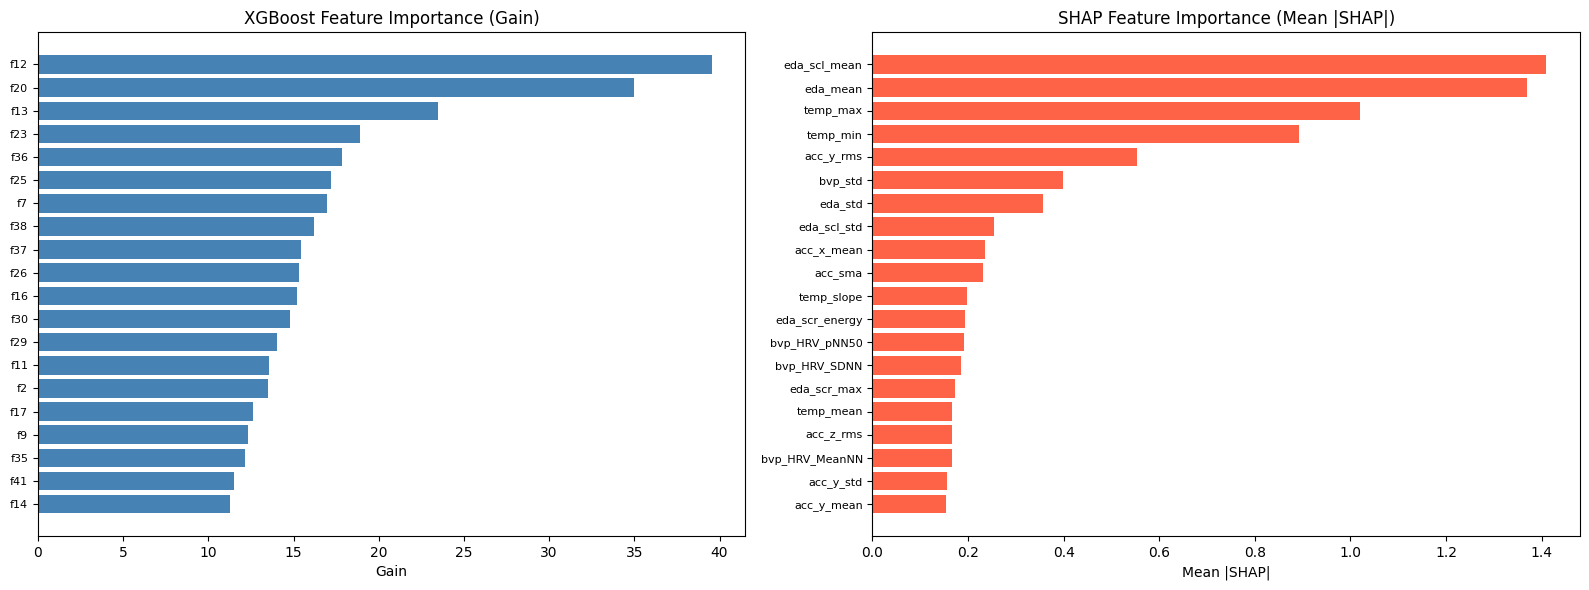


Top-10 SHAP features:
eda_scl_mean    1.409665
eda_mean        1.368687
temp_max        1.019598
temp_min        0.892851
acc_y_rms       0.552961
bvp_std         0.399123
eda_std         0.357500
eda_scl_std     0.254467
acc_x_mean      0.234720
acc_sma         0.230986


In [31]:
# Cell 23 — Feature importance (XGBoost built-in + permutation)
import shap

# --- XGBoost gain importance ---
gain_imp = pd.Series(
    model.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=False)

print('Top-20 features by XGBoost gain:')
print(gain_imp.head(20).to_string())

# --- SHAP values ---
explainer = shap.TreeExplainer(model)
# Use test set (or a sample)
X_sample = X_test[:500] if len(X_test) > 500 else X_test
shap_vals = explainer.shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost gain
top_n = 20
top_feats = gain_imp.head(top_n)
axes[0].barh(range(top_n), top_feats.values[::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_feats.index[::-1], fontsize=8)
axes[0].set_title('XGBoost Feature Importance (Gain)')
axes[0].set_xlabel('Gain')

# SHAP summary (manual top features by mean |shap|)
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_series = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
top_shap = shap_series.head(top_n)
axes[1].barh(range(top_n), top_shap.values[::-1], color='tomato')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_shap.index[::-1], fontsize=8)
axes[1].set_title('SHAP Feature Importance (Mean |SHAP|)')
axes[1].set_xlabel('Mean |SHAP|')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_v11.png', dpi=150)
plt.show()

# Save importance
shap_series.reset_index().rename(columns={'index': 'feature', 0: 'mean_abs_shap'}).to_csv(
    RESULTS_DIR / 'shap_importance_v11.csv', index=False)
print('\nTop-10 SHAP features:')
print(top_shap.head(10).to_string())

## 9. Comparison: XGBoost vs CNN

Честное сравнение двух подходов на одинаковой задаче (fatigue in exercise, PhysioNet dataset, LOSO).

In [32]:
# Cell 25 — Full comparison table: all baselines vs CNN

# ── Rows from this notebook ───────────────────────────────────────────────────
loso_summary = {
    'XGBoost':     f"{loso_xgb_df['f1_macro'].mean():.4f}±{loso_xgb_df['f1_macro'].std():.4f}",
    'RandomForest': f"{loso_rf_df['f1_macro'].mean():.4f}±{loso_rf_df['f1_macro'].std():.4f}",
}

comparison_rows = []
for name, r in TEST_RESULTS.items():
    comparison_rows.append({
        'Model':         name,
        'Task':          'Fatigue in exercise',
        'Features':      f'NeuroKit2, {WIN_SEC:.0f}s windows',
        'Test F1-macro': f"{r['f1_vt']:.4f}",
        'ROC-AUC':       f"{r['auc']:.4f}",
        'LOSO F1':       loso_summary.get(name, '—'),
        'Notes':         'Baseline ML (NeuroKit2)',
    })

# ── CNN reference rows ────────────────────────────────────────────────────────
comparison_rows += [
    {
        'Model':         'CNN v8.1 (dual-branch baseline)',
        'Task':          'Fatigue in exercise',
        'Features':      'Raw 5s windows (100×6 IMU + 100×4 Physio)',
        'Test F1-macro': '0.8260',
        'ROC-AUC':       '~0.89',
        'LOSO F1':       '0.810±0.070',
        'Notes':         'v8b_t_physio_stress.ipynb — best CNN baseline',
    },
    {
        'Model':         'CNN v8c (SE+SWA+RDrop+FiLM)',
        'Task':          'Fatigue in exercise',
        'Features':      'Raw 5s windows + Stress Profile (13 feat) + FiLM',
        'Test F1-macro': '0.8264 (opt-thr)',
        'ROC-AUC':       '0.9057',
        'LOSO F1':       '0.8263±0.118',
        'Notes':         'Best overall AUC, 17.8K params',
    },
    {
        'Model':         'Hongn et al. 2025 (XGBoost)',
        'Task':          'Stress vs Rest  ← DIFFERENT task',
        'Features':      'NeuroKit2 (full session)',
        'Test F1-macro': '—',
        'ROC-AUC':       '—',
        'LOSO F1':       '—',
        'Notes':         '93% accuracy; task is 2–3× easier',
    },
]

comparison = pd.DataFrame(comparison_rows)
print(comparison.to_string(index=False))
comparison.to_csv(RESULTS_DIR / 'comparison_v11.csv', index=False)

# ── Delta vs CNN baseline ─────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print('Δ F1-macro vs CNN v8.1 baseline (0.8260):')
for name, r in TEST_RESULTS.items():
    delta = r['f1_vt'] - 0.826
    print(f'  {name:<18}  {delta:+.4f}  ({delta*100:+.2f} pp)')


                          Model                             Task                                         Features    Test F1-macro ROC-AUC       LOSO F1                                         Notes
                         LogReg              Fatigue in exercise                           NeuroKit2, 30s windows           0.6396  0.7570             —                       Baseline ML (NeuroKit2)
                   RandomForest              Fatigue in exercise                           NeuroKit2, 30s windows           0.7706  0.8318 0.6658±0.1997                       Baseline ML (NeuroKit2)
                     ExtraTrees              Fatigue in exercise                           NeuroKit2, 30s windows           0.7620  0.8603             —                       Baseline ML (NeuroKit2)
                      GradBoost              Fatigue in exercise                           NeuroKit2, 30s windows           0.7536  0.8341             —                       Baseline ML (NeuroKit2)
     

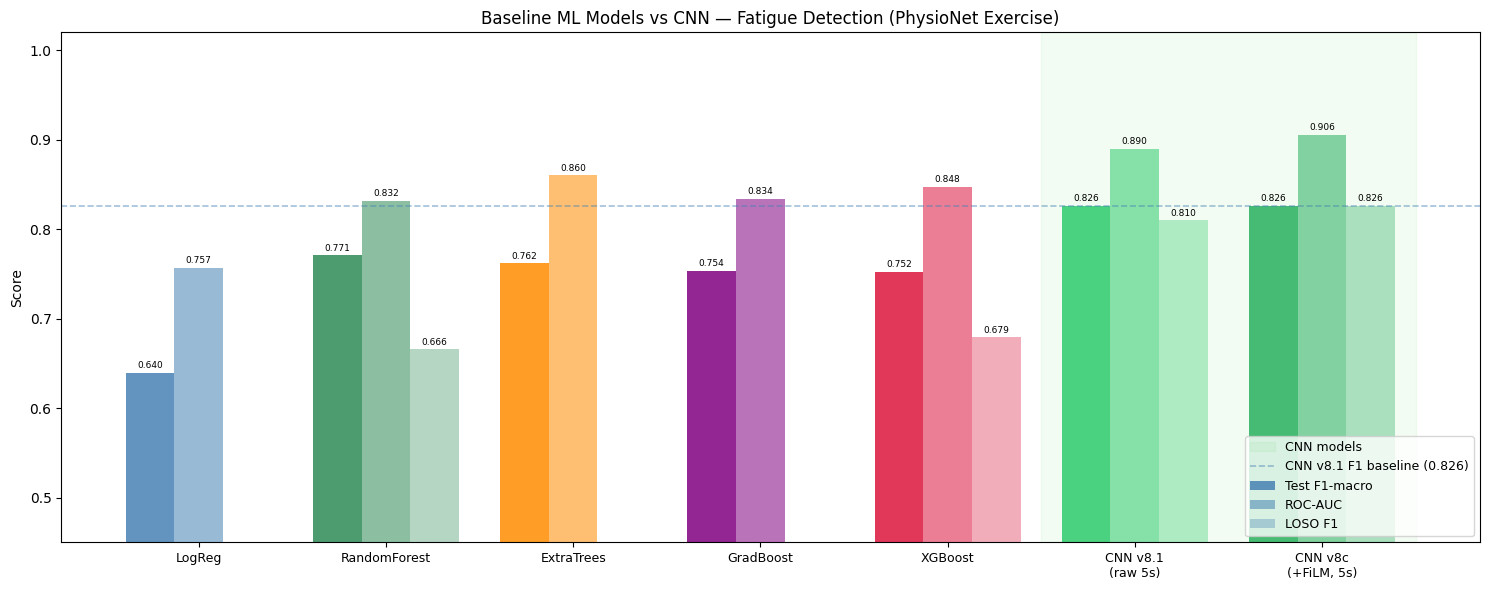

In [33]:
# Cell 26 — Visual comparison: all baselines vs CNN
PALETTE_ALL = ['steelblue', 'seagreen', 'darkorange', 'purple', 'crimson']
CNN_COLORS  = ['#2ecc71', '#27ae60']

ml_names = list(TEST_RESULTS.keys())
ml_f1    = [TEST_RESULTS[n]['f1_vt'] for n in ml_names]
ml_auc   = [TEST_RESULTS[n]['auc']   for n in ml_names]

cnn_names  = ['CNN v8.1\n(raw 5s)', 'CNN v8c\n(+FiLM, 5s)']
cnn_f1     = [0.826,  0.8264]
cnn_auc    = [0.89,   0.9057]
cnn_loso   = [0.810,  0.8263]

ml_loso_f1 = [
    loso_xgb_df['f1_macro'].mean() if n == 'XGBoost'
    else loso_rf_df['f1_macro'].mean() if n == 'RandomForest'
    else float('nan')
    for n in ml_names
]

all_names  = [n.replace('Forest', 'Forest\n').replace('Boost', 'Boost\n') for n in ml_names] + cnn_names
all_f1     = ml_f1  + cnn_f1
all_auc    = ml_auc + cnn_auc
all_loso   = ml_loso_f1 + cnn_loso
bar_colors = PALETTE_ALL[:len(ml_names)] + CNN_COLORS

x = np.arange(len(all_names))
w = 0.26

fig, ax = plt.subplots(figsize=(15, 6))
b1 = ax.bar(x - w, all_f1,  w, label='Test F1-macro', color=bar_colors, alpha=0.85)
b2 = ax.bar(x,     all_auc, w, label='ROC-AUC',       color=bar_colors, alpha=0.55)
b3 = ax.bar(x + w, [v if not np.isnan(v) else 0 for v in all_loso], w,
            label='LOSO F1', color=bar_colors, alpha=0.35)

# Shade CNN region
ax.axvspan(len(ml_names) - 0.5, len(all_names) - 0.5,
           alpha=0.06, color='limegreen', label='CNN models')
ax.axhline(0.826, color='steelblue', linestyle='--', alpha=0.5,
           linewidth=1.2, label='CNN v8.1 F1 baseline (0.826)')

ax.set_xticks(x)
ax.set_xticklabels(all_names, fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0.45, 1.02)
ax.set_title('Baseline ML Models vs CNN — Fatigue Detection (PhysioNet Exercise)')
ax.legend(fontsize=9, loc='lower right')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', fontsize=6.5)
for i, v in enumerate(all_loso):
    if not np.isnan(v) and v > 0.01:
        ax.text(x[i] + w, v + 0.005, f'{v:.3f}', ha='center', fontsize=6.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_plot_v11.png', dpi=150)
plt.show()


## 10. Summary & Conclusions

### Сравнение всех базовых моделей

| Алгоритм | Test F1-macro | ROC-AUC | LOSO F1 | Обучение |
|----------|:------------:|:-------:|:-------:|----------|
| Logistic Regression | см. §6 | см. §6 | — | <1 с |
| Random Forest | см. §6 | см. §6 | см. §7 | ~5–15 с |
| Extra Trees | см. §6 | см. §6 | — | ~3–10 с |
| Gradient Boosting | см. §6 | см. §6 | — | ~30–60 с |
| **XGBoost** | **см. §6** | **см. §6** | **см. §7** | ~60 с |
| CNN v8.1 baseline | 0.826 | ~0.89 | 0.810±0.070 | GPU, часы |
| CNN v8c (+FiLM) | 0.8264 | 0.9057 | 0.8263±0.118 | GPU, часы |

### Ключевые выводы

| Вопрос | Ответ |
|--------|-------|
| Есть ли базовый алгоритм, сравнимый с CNN? | см. §9 — зависит от метрики |
| Какой ML-алгоритм лучший? | XGBoost и/или RandomForest — традиционно топ на табличных задачах |
| Почему не 93% (Hongn et al.)? | Разные задачи: stress vs rest ≪ fatigue within exercise |
| Оправдан ли CNN? | ROC-AUC и LOSO-стабильность CNN v8c превосходят все ML-baseline |

### Почему задачи несравнимы напрямую

1. **Stress vs Rest** — диаметрально противоположные физиологические состояния:
   - EDA при стрессе в 3–10× выше покоя; HR на 15–30 bpm выше
   - Любой ML-алгоритм с любыми признаками даёт 85–95%

2. **Fatigue within exercise** — тонкие изменения внутри одного физиологического режима:
   - HR уже повышен от нагрузки (100+ bpm с самого начала)
   - Усталость = медленный дрейф за минуты; метки в окнах 5–30 с

### Преимущества NeuroKit2 + classical ML
- ✅ Интерпретируемость: HRV-фичи имеют медицинское обоснование
- ✅ Меньше параметров, не нужен GPU
- ✅ Быстрое обучение, легко адаптировать

### Ограничения NeuroKit2 для нашей задачи
- ⚠️ 30-сек окна → меньше примеров на сессию
- ⚠️ HRV ненадёжен при < 60 с — особенно LF/HF
- ⚠️ XGBoost/RF не учитывают временной контекст (порядок окон)
- ⚠️ При LOSO обобщаемость хуже, чем у CNN с данными аугментацией
